# Annual GDP Growth and Debt of the 27 EU-countries

We look at the annual gdp growth and debt of the current 27 EU-countries for the period from 2000 until 2022. 
The data set for the annual gdp growth is from the World Bank and directly contains the current 27 EU-countries and the period from 2000 until 2022. It can be downloaded here: https://databank.worldbank.org/reports.aspx?source=2&series=NY.GDP.MKTP.KD.ZG&country=#.
The data set for the annual debt comes from Danmarks Statistics and can be downloaded here: 
https://www.statbank.dk/20172. The debt is given in € (Mill. Euro (current prices)).

Here we import the relevant packages:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets # for interactive plots/buttons

plt.rcParams.update({"axes.grid":True,"grid.color":"black","grid.alpha":"0.25","grid.linestyle":"--"})
plt.rcParams.update({'font.size': 14})
# user written modules
#import dataproject


# Read and clean data

We downloaded both data sets and saved them as xlsx. Therefore, we load the data first.

First the data for the annual gdp growth (in %):

In [ ]:
filename_world_bank_update = 'gdp_growth_world_bank_update.xlsx'
gdp_world_bank = pd.read_excel(filename_world_bank_update)
gdp_world_bank.head(5)

,Series Name,Series Code,Country Name,Country Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
0,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Austria,AUT,3.375722,1.267168,1.651554,0.941471,2.735120,2.244065,...,0.025505,0.661273,1.014502,1.989437,2.258572,2.425385,1.450529,-6.632991,4.237867,4.806430
1,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Belgium,BEL,3.716679,1.099619,1.706885,1.037983,3.571204,2.321737,...,0.459242,1.578533,2.041459,1.266686,1.619580,1.792945,2.240835,-5.260779,6.850996,3.009903
2,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Greece,GRC,3.919771,4.131612,3.922872,5.794532,5.060992,0.599142,...,-2.515997,0.475696,-0.196088,-0.487173,1.092149,1.668429,1.879490,-9.316436,8.379944,5.557287
3,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Italy,ITA,3.786955,1.951372,0.253943,0.138627,1.423594,0.817849,...,-1.841065,-0.004548,0.778304,1.293463,1.667859,0.925811,0.483198,-8.974192,8.313760,3.724549
4,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Lithuania,LTU,3.695525,6.526109,6.751415,10.565957,6.569490,7.732368,...,3.550073,3.537010,2.024584,2.518828,4.282597,3.993310,4.665678,-0.024612,6.284710,2.440175


Then we load the second data set containing the annual debt:

In [ ]:
filename_debt = 'new_debt_data.xlsx'

# removing 2 irrelevant rows
debt = pd.read_excel(filename_debt, skiprows=2)
debt.head(5)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,2000,2001,2002,2003,2004,2005,2006,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Mill. Euro (current prices),Government EMU-debt,Belgium,280959.5,286055.5,288110.8,285866.7,288418.8,294975.3,297494.9,...,414432.4,431384.3,438504.8,451619.9,454048.4,459388.5,467249.4,515211.9,548456.4,578063.2
1,NaN,NaN,Bulgaria,10177.1,10269.8,8890.3,8126.5,7526.2,6388.6,5721.0,...,7147.6,11619.3,11871.6,14188.1,13182.6,12427.2,12311.1,15131.7,17013.2,19352.9
2,NaN,NaN,Cyprus,6024.5,6660.9,7339.8,8184.8,9055.9,9595.9,9597.7,...,18706.5,19013.8,19296.8,19631.5,18935.6,21343.9,21565.9,25388.1,24744.7,23767.3
3,NaN,NaN,Denmark,93084.0,89464.7,93174.5,89061.4,89394.7,79532.5,71183.3,...,113943.4,117801.4,108532.4,105450.1,105727.0,102597.3,104187.6,131859.7,123539.1,113586.0
4,NaN,NaN,Estonia,315.6,333.4,442.9,489.7,499.9,533.1,628.1,...,1934.2,2129.9,2077.4,2174.1,2174.0,2127.4,2373.4,5094.4,5533.5,6657.4


By looking at the initial data sets we see that both are in a wide data format. 
For both data sets we need to do some data cleaning. 
For example, we saw that the column headers have two rows in the gdp data set. However, we would like to delete the second row such that there is only one row for the header. There also some unnecessary columns in the current gdp data set (for example Series Code or Country Code). These will be deleted. 

In [ ]:
## data cleaning for the first data set
## delete irrelevant columns
del gdp_world_bank["Series Code"]
del gdp_world_bank["Country Code"]
gdp_world_bank.head(5)


# Removing the part in brackets
gdp_world_bank.columns = [name.split(' [')[0] for name in gdp_world_bank.columns]
gdp_world_bank.head(5)

## rename variables 
gdp_world_bank.rename(columns = {'Series Name':'Variable'}, inplace=True)
gdp_world_bank.rename(columns = {'Country Name':'Countries'}, inplace=True)



For the debt data set, we do similar data cleaning: We remove the first two columns and rename the column containing the 27 countries.

In [ ]:
# removing 2 columns
debt = debt.iloc[:, 2:]

# renaming
debt.rename(columns = {'Unnamed: 2':'Countries'}, inplace=True)

# Renaming countries to match debt dataset with gdp dataset
country_renames = {
    'Slovakia': 'Slovak Republic',
    'Czech Republic': 'Czechia'
}
debt['Countries'] = debt['Countries'].replace(country_renames)

The cleaned data sets look like these: 

In [ ]:
gdp_world_bank.head(5)

,Variable,Countries,2000,2001,2002,2003,2004,2005,2006,2007,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,GDP growth (annual %),Austria,3.375722,1.267168,1.651554,0.941471,2.735120,2.244065,3.454042,3.727415,...,0.025505,0.661273,1.014502,1.989437,2.258572,2.425385,1.450529,-6.632991,4.237867,4.806430
1,GDP growth (annual %),Belgium,3.716679,1.099619,1.706885,1.037983,3.571204,2.321737,2.552350,3.676881,...,0.459242,1.578533,2.041459,1.266686,1.619580,1.792945,2.240835,-5.260779,6.850996,3.009903
2,GDP growth (annual %),Greece,3.919771,4.131612,3.922872,5.794532,5.060992,0.599142,5.652434,3.273747,...,-2.515997,0.475696,-0.196088,-0.487173,1.092149,1.668429,1.879490,-9.316436,8.379944,5.557287
3,GDP growth (annual %),Italy,3.786955,1.951372,0.253943,0.138627,1.423594,0.817849,1.790640,1.487073,...,-1.841065,-0.004548,0.778304,1.293463,1.667859,0.925811,0.483198,-8.974192,8.313760,3.724549
4,GDP growth (annual %),Lithuania,3.695525,6.526109,6.751415,10.565957,6.569490,7.732368,7.414121,11.107480,...,3.550073,3.537010,2.024584,2.518828,4.282597,3.993310,4.665678,-0.024612,6.284710,2.440175


In [ ]:
debt.head(5)

,Countries,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Belgium,280959.5,286055.5,288110.8,285866.7,288418.8,294975.3,297494.9,300063.7,327683.2,...,414432.4,431384.3,438504.8,451619.9,454048.4,459388.5,467249.4,515211.9,548456.4,578063.2
1,Bulgaria,10177.1,10269.8,8890.3,8126.5,7526.2,6388.6,5721.0,5296.9,4848.6,...,7147.6,11619.3,11871.6,14188.1,13182.6,12427.2,12311.1,15131.7,17013.2,19352.9
2,Cyprus,6024.5,6660.9,7339.8,8184.8,9055.9,9595.9,9597.7,9461.9,8658.6,...,18706.5,19013.8,19296.8,19631.5,18935.6,21343.9,21565.9,25388.1,24744.7,23767.3
3,Denmark,93084.0,89464.7,93174.5,89061.4,89394.7,79532.5,71183.3,63755.0,80547.5,...,113943.4,117801.4,108532.4,105450.1,105727.0,102597.3,104187.6,131859.7,123539.1,113586.0
4,Estonia,315.6,333.4,442.9,489.7,499.9,533.1,628.1,617.5,749.4,...,1934.2,2129.9,2077.4,2174.1,2174.0,2127.4,2373.4,5094.4,5533.5,6657.4


In the following we change the data format from wide to long. Especially for the later merge of both data frames, it makes more sense to have the data sets in long format.

In [ ]:
# from wide to long
gdp_growth_long = pd.melt(gdp_world_bank, id_vars=['Countries'], value_vars = ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
                                                                                '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020','2021','2022'],
var_name='year', value_name='annual_gdp_growth')

# changing index from (0,1,2...) to countries
#gdp_growth_long = gdp_growth_long.set_index('Countries')

gdp_growth_long.head(5)

,Countries,year,annual_gdp_growth
0,Austria,2000,3.375722
1,Belgium,2000,3.716679
2,Greece,2000,3.919771
3,Italy,2000,3.786955
4,Lithuania,2000,3.695525


In [ ]:
# wide to long
debt_long = pd.melt(debt, id_vars=['Countries'], var_name='year', value_name='debt')
debt_long.head(5)

# changing index from (0,1,2...) to countries
#debt_long = debt_long.set_index('Countries')

debt_long.head(5)

,Countries,year,debt
0,Belgium,2000,280959.5
1,Bulgaria,2000,10177.1
2,Cyprus,2000,6024.5
3,Denmark,2000,93084.0
4,Estonia,2000,315.6


## Exploring data sets

We know look at summary statistics of both data sets. Since we have both data formats, we are also able to look at a summary across countries to compare different years in the wide format. This can be helpful to identify outlier-years.

In [ ]:
## summary statistic of gdp growth for the wide format: 
## get a summary statistic for the wide format for each year across different countries 
description_gdp_wide = gdp_world_bank.describe()
description_gdp_wide


,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,...,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,5.130061,3.045232,3.197920,3.209616,4.373774,4.004903,5.180710,5.136779,1.347001,-5.352893,...,0.286484,2.205493,3.653492,2.580062,3.962905,3.383565,2.965571,-4.354673,7.215687,3.855848
std,3.467922,1.834668,2.255573,2.791392,2.281927,2.656944,2.465906,2.831966,3.109683,3.972067,...,2.177185,2.273906,4.593814,1.265638,2.383059,2.009536,1.655607,3.639918,2.884774,2.193676
min,1.166527,-1.174697,-0.197974,-0.930521,0.140269,0.599142,1.625034,0.277373,-5.132001,-14.838608,...,-6.553078,-1.829309,-0.196088,-0.487173,1.092149,0.925811,0.483198,-11.167298,2.838180,-1.287411
25%,3.706102,1.812570,1.610705,0.989727,2.782437,2.282901,3.638715,3.356484,-0.317674,-6.145852,...,-0.722224,0.870819,1.822533,2.004461,2.624078,1.907544,1.861231,-7.086725,5.942231,2.447467
50%,4.001029,3.074355,2.730948,2.960260,4.336856,3.506835,4.713829,5.075022,0.959879,-4.657331,...,0.437591,1.902173,2.342591,2.518828,3.192410,2.820323,2.682760,-3.886084,6.844522,3.724549
75%,5.460843,4.013324,5.222139,4.655702,5.169937,5.296393,6.449035,7.020848,3.098127,-3.293048,...,1.181195,2.889763,3.861889,3.096669,4.977699,4.242378,3.944176,-2.389739,8.120981,5.159247
max,19.681269,6.526109,7.088129,10.565957,10.428113,10.720366,11.971836,11.107480,9.307467,2.832184,...,5.473356,8.828999,24.475253,6.454554,10.869269,8.470295,7.058727,6.617195,15.125220,9.433022


In [ ]:
descripton_debt_wide = debt.describe()
descripton_debt_wide

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
count,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,...,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01
mean,1.935240e+05,2.002349e+05,2.070149e+05,2.165488e+05,2.275294e+05,2.377860e+05,2.434668e+05,2.477750e+05,2.669535e+05,2.971351e+05,...,3.788675e+05,3.883111e+05,3.936111e+05,4.004164e+05,4.050799e+05,4.086630e+05,4.120407e+05,4.573346e+05,4.821909e+05,4.998471e+05
std,3.672209e+05,3.780732e+05,3.898513e+05,4.105146e+05,4.298885e+05,4.503465e+05,4.634989e+05,4.712226e+05,4.957783e+05,5.408636e+05,...,6.582775e+05,6.729476e+05,6.804660e+05,6.932865e+05,7.027566e+05,7.106377e+05,7.196171e+05,7.925658e+05,8.375858e+05,8.674273e+05
min,3.156000e+02,3.334000e+02,4.429000e+02,4.897000e+02,4.999000e+02,5.331000e+02,6.281000e+02,6.175000e+02,7.494000e+02,1.023100e+03,...,1.934200e+03,2.129900e+03,2.077400e+03,2.174100e+03,2.174000e+03,2.127400e+03,2.373400e+03,5.094400e+03,5.533500e+03,6.657400e+03
25%,6.778650e+03,8.161100e+03,8.115050e+03,8.155650e+03,8.291050e+03,8.643000e+03,8.899600e+03,8.737750e+03,8.460550e+03,1.132825e+04,...,2.211330e+04,2.461685e+04,2.569210e+04,2.569375e+04,2.541430e+04,2.679510e+04,2.665915e+04,3.140620e+04,3.181160e+04,3.345700e+04
50%,3.949400e+04,4.096920e+04,4.198740e+04,4.340930e+04,5.050510e+04,5.407560e+04,6.229880e+04,6.375500e+04,7.331730e+04,8.020000e+04,...,1.139434e+05,1.178014e+05,1.085324e+05,1.054501e+05,1.057270e+05,1.025973e+05,1.041876e+05,1.318597e+05,1.235391e+05,1.344690e+05
75%,1.447312e+05,1.550626e+05,1.613530e+05,1.670990e+05,1.786337e+05,1.941898e+05,2.030000e+05,2.122948e+05,2.332925e+05,2.655383e+05,...,2.918638e+05,2.998150e+05,3.019968e+05,3.056282e+05,3.037162e+05,3.100714e+05,3.058422e+05,3.287845e+05,3.440660e+05,3.536477e+05
max,1.353569e+06,1.420027e+06,1.436142e+06,1.471326e+06,1.526400e+06,1.591581e+06,1.657334e+06,1.677650e+06,1.738647e+06,1.839233e+06,...,2.201918e+06,2.203743e+06,2.239410e+06,2.285705e+06,2.329932e+06,2.381640e+06,2.410323e+06,2.657352e+06,2.823692e+06,2.949331e+06


Using the summary statistics we could plot the time series of the dispersion of annual gdp growth and debt: 

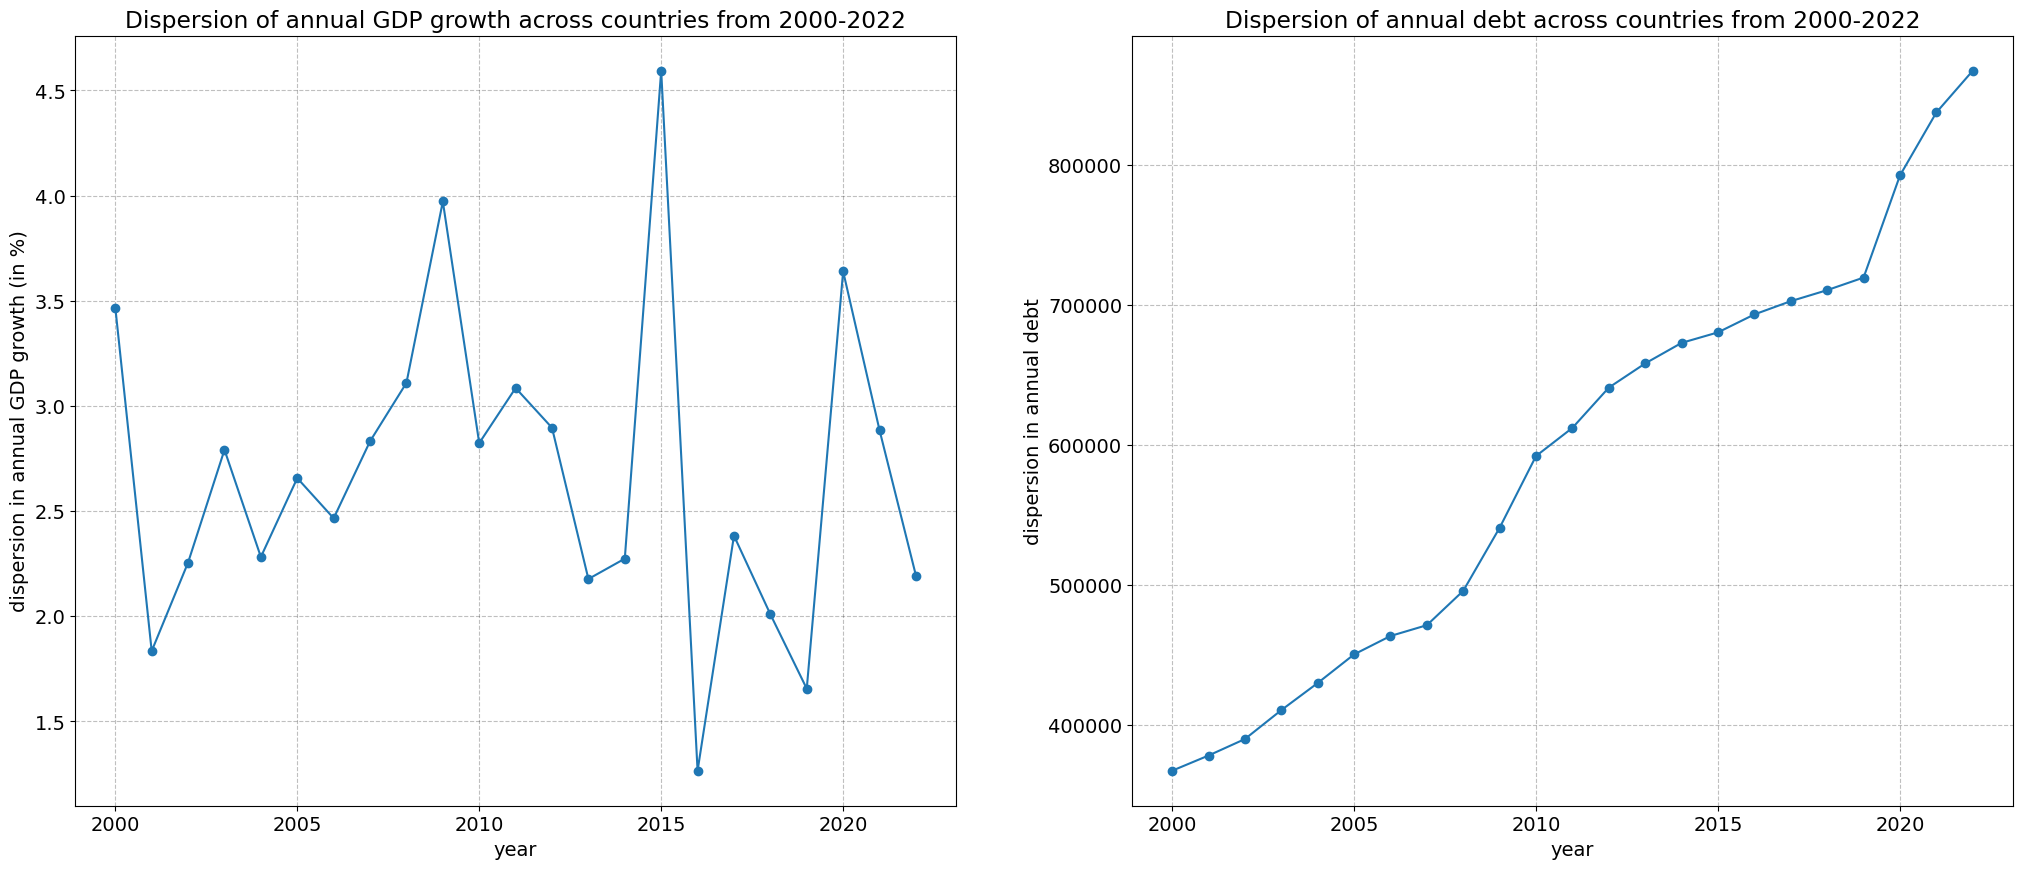

In [ ]:

## plotting yearly dispersion across countries
fig = plt.figure(frameon=True,figsize=(25,10), dpi=100)
ax = fig.add_subplot(1,2,1)

## plot dispersion 
description_gdp_wide.loc["std"].plot(ax=ax,style='-o')
#ax.legend(bbox_to_anchor=(0.185, 0.18))
ax.set_xlabel('year')
#plt.xticks(rotation=45)
ax.set_ylabel('dispersion in annual GDP growth (in %)')
ax.set_title('Dispersion of annual GDP growth across countries from 2000-2022')


## plotting yearly dispersion across countries
az = fig.add_subplot(1,2,2)

#ax.plot(gdp_growth['year'], gdp_growth['year_sd_gdp_growth'])
descripton_debt_wide.loc["std"].plot(ax=az,style='-o')
#ax.legend(bbox_to_anchor=(0.185, 0.18))
az.set_xlabel('year')
#plt.xticks(rotation=45)
az.set_ylabel('dispersion in annual debt')
az.set_title('Dispersion of annual debt across countries from 2000-2022')
plt.show();


HERE WE NEED TO DESCRIBE THE TWO PLOTS!!
There is a trend in the dispersion of annual debt across countries. Whereas, the GDP growth fluctuates more. 

Using the data sets in long format, we can create interactive plots to look at the annual gdp growth and debt of each country over time: 

In [ ]:
# This function tells the widget how the plot should look at a specific parametrization 
def interactive_figure(country):
    # Create a figure
    fig = plt.figure(frameon=True,figsize=(30,12), dpi=100)
    ax = fig.add_subplot(1,2,1)
    
    # Plot the selected country's GDP growth time series
    selected_country_data = gdp_growth_long[gdp_growth_long['Countries'] == country]
    ax.plot(selected_country_data['year'], selected_country_data['annual_gdp_growth'])
    
    # Set the title
    ax.set_xlabel('year')
    plt.xticks(rotation=45)
    ax.set_ylabel('annual gdp growth (in %)')
    ax.set_title("Time Series of GDP Growth for {}".format(country))


    az = fig.add_subplot(1,2,2)
    
    # Plot the selected country's debt time series
    selected_country_data = debt_long[debt_long['Countries'] == country]
    az.plot(selected_country_data['year'], selected_country_data['debt'])
    
    # Set the title
    az.set_xlabel('year')
    plt.xticks(rotation=45)
    az.set_ylabel('annual gdp growth (in %)')
    az.set_title("Time Series of debt for {}".format(country))
    
    # Show the plot
    plt.show()

In [ ]:
# Define the list of countries for which we want to have a drop down 
countries = list(gdp_world_bank['Countries'])

In [ ]:
# Create the dropdown widget
# semikolon avoids additional text to be printed 
widgets.interact(interactive_figure, country=countries);

interactive(children=(Dropdown(description='country', options=('Austria', 'Belgium', 'Greece', 'Italy', 'Lithu…

We can also add summmary statistics for the data in long format:

In [ ]:
# Sorting the countries together
gdp_growth_long_sort = gdp_growth_long.sort_values(['Countries','year'])

# calculating the deviation from mean
# First i calculate mean gdp growth per country over all years
gdp_growth_mean = gdp_growth_long_sort.groupby('Countries')['annual_gdp_growth'].mean().rename('country_mean_gdp_growth')

# Joining the mean gdp growth back to the original dataframe
gdp_growth_long = gdp_growth_long_sort.join(gdp_growth_mean, on='Countries')

# Calculating the deviation from each country's mean gdp growth
gdp_growth_long['gdp_mean_dev'] = gdp_growth_long['annual_gdp_growth'] - gdp_growth_long['country_mean_gdp_growth']

gdp_growth_long.head(30)

,Countries,year,annual_gdp_growth,country_mean_gdp_growth,gdp_mean_dev
0,Austria,2000,3.375722,1.511706,1.864016
27,Austria,2001,1.267168,1.511706,-0.244538
54,Austria,2002,1.651554,1.511706,0.139847
81,Austria,2003,0.941471,1.511706,-0.570236
108,Austria,2004,2.735120,1.511706,1.223414
135,Austria,2005,2.244065,1.511706,0.732359
162,Austria,2006,3.454042,1.511706,1.942335
189,Austria,2007,3.727415,1.511706,2.215709
216,Austria,2008,1.460424,1.511706,-0.051283
243,Austria,2009,-3.764578,1.511706,-5.276285


In [ ]:
# Sorting the countries together
debt_long_sort = debt_long.sort_values(['Countries','year'])

# calculating the deviation from mean
# First i calculate mean gdp growth per country over all years
debt_mean = debt_long_sort.groupby('Countries')['debt'].mean().rename('country_mean_debt')

# Joining the mean gdp growth back to the original dataframe
debt_long = debt_long_sort.join(debt_mean, on='Countries')

# Calculating the deviation from each country's mean gdp growth
debt_long['debt_mean_dev'] = debt_long['debt'] - debt_long['country_mean_debt']

debt_long.head(30)

,Countries,year,debt,country_mean_debt,debt_mean_dev
26,Austria,2000,141245.5,237894.756522,-96649.256522
53,Austria,2001,147154.2,237894.756522,-90740.556522
80,Austria,2002,151295.9,237894.756522,-86598.856522
107,Austria,2003,152688.1,237894.756522,-85206.656522
134,Austria,2004,157985.4,237894.756522,-79909.356522
161,Austria,2005,174403.5,237894.756522,-63491.256522
188,Austria,2006,180270.0,237894.756522,-57624.756522
215,Austria,2007,184674.5,237894.756522,-53220.256522
242,Austria,2008,201809.9,237894.756522,-36084.856522
269,Austria,2009,230014.6,237894.756522,-7880.156522


# Merge data sets

We will join the two data sets by country and year. For the merge we use the data sets in long format. Then we do a scatter plot where each point represents the average gdp growth and average debt for each seperate country. 


In [ ]:
gdp_debt_merge = pd.merge(gdp_growth_long, debt_long, on=['Countries','year'], how='left')


# Calculate the ratio of average GDP growth to average debt
gdp_debt_merge['gdp_to_debt_ratio'] = gdp_debt_merge['country_mean_gdp_growth'] / gdp_debt_merge['country_mean_debt']

gdp_debt_merge.head()


,Countries,year,annual_gdp_growth,country_mean_gdp_growth,gdp_mean_dev,debt,country_mean_debt,debt_mean_dev,gdp_to_debt_ratio
0,Austria,2000,3.375722,1.511706,1.864016,141245.5,237894.756522,-96649.256522,0.000006
1,Austria,2001,1.267168,1.511706,-0.244538,147154.2,237894.756522,-90740.556522,0.000006
2,Austria,2002,1.651554,1.511706,0.139847,151295.9,237894.756522,-86598.856522,0.000006
3,Austria,2003,0.941471,1.511706,-0.570236,152688.1,237894.756522,-85206.656522,0.000006
4,Austria,2004,2.735120,1.511706,1.223414,157985.4,237894.756522,-79909.356522,0.000006


<Axes: xlabel='Countries'>

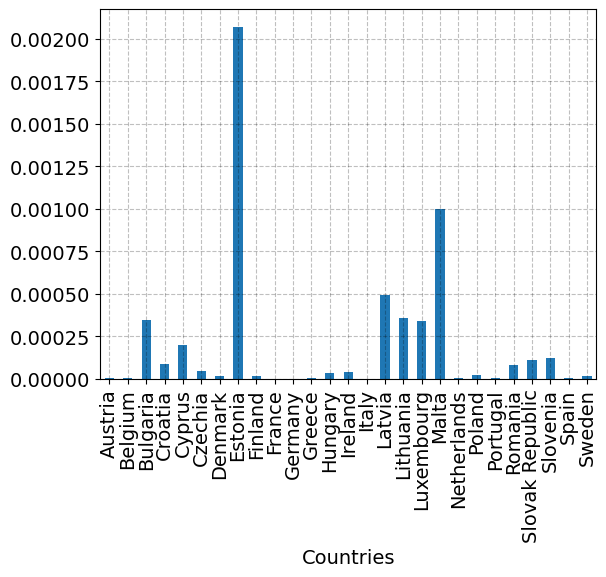

In [ ]:
# plotting the gdp_growth / debt ratio
average_debt = debt_long.groupby('Countries')['debt'].mean()
average_gdp_growth = gdp_growth_long.groupby('Countries')['annual_gdp_growth'].mean()

ratio = average_gdp_growth / average_debt

ratio.plot.bar()

/var/folders/cp/xm03dlvj3sgffp11rh782s380000gn/T/ipykernel_93221/3025415529.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab20', len(gdp_debt_merge['Countries'].unique()))


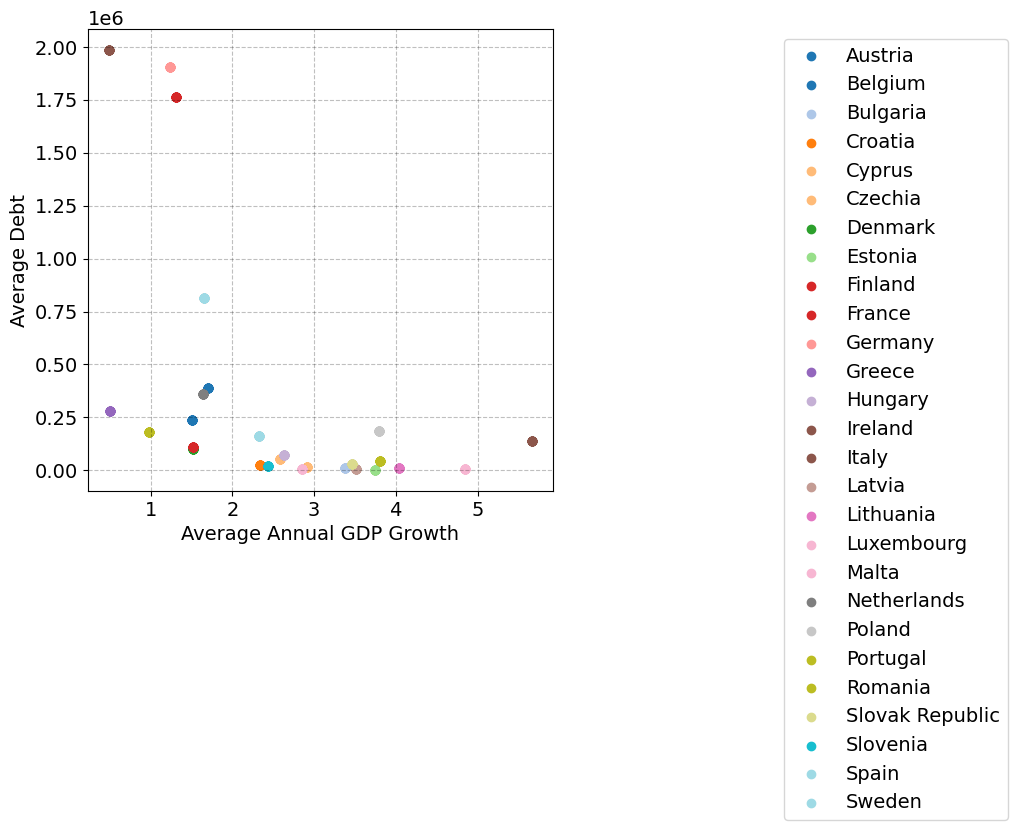

In [ ]:

# Create a color map for different countries
color_map = plt.cm.get_cmap('tab20', len(gdp_debt_merge['Countries'].unique()))


print(color_map)
# Create a scatter plot
fig = plt.figure(frameon=True, figsize=(6, 6), dpi=100)
ax_A = fig.add_subplot(1, 1, 1)

# Set labels
ax_A.set_xlabel("Average Annual GDP Growth")
ax_A.set_ylabel("Average Debt")

# Iterate over each country's data and plot them separately with different colors
for i, (country, data) in enumerate(gdp_debt_merge.groupby('Countries')):
    ax_A.scatter(data['country_mean_gdp_growth'], data['country_mean_debt'], label=country, color=color_map(i))

# Add legend
ax_A.legend(bbox_to_anchor=(2, 1))

# Show the plot
plt.show()


# Analysis

To get a quick overview of the data, we show some **summary statistics** on a meaningful aggregation. 

MAKE FURTHER ANALYSIS. EXPLAIN THE CODE BRIEFLY AND SUMMARIZE THE RESULTS.

# Conclusion

ADD CONCISE CONLUSION.

ADD SOMETHING

The data set is from the World Bank and contains the current 27 EU-countries. It contains time series data for the GDP growth (in %) from 2000 until 2022. It can be downloaded here: https://databank.worldbank.org/reports.aspx?source=2&series=NY.GDP.MKTP.KD.ZG&country=#.

First we load the essential packages from Python.

In [16]:
# autoreload modules when code is run. Otherwise, python will not see recent changes. 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import numpy as np
import pandas as pd

In [18]:
import ipywidgets as widgets # for interactive plots/buttons 

In [19]:
import matplotlib.pyplot as plt ## for general plots 
plt.rcParams.update({"axes.grid":True,"grid.color":"black","grid.alpha":"0.25","grid.linestyle":"--"})
plt.rcParams.update({'font.size': 14})

Now we load the data and look at the first five rows to get a first impression of the data set.

In [20]:
filename_world_bank_update = 'gdp_growth_world_bank_update.xlsx'
gdp_world_bank = pd.read_excel(filename_world_bank_update)
gdp_world_bank.head(5)

,Series Name,Series Code,Country Name,Country Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
0,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Austria,AUT,3.375722,1.267168,1.651554,0.941471,2.735120,2.244065,...,0.025505,0.661273,1.014502,1.989437,2.258572,2.425385,1.450529,-6.632991,4.237867,4.806430
1,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Belgium,BEL,3.716679,1.099619,1.706885,1.037983,3.571204,2.321737,...,0.459242,1.578533,2.041459,1.266686,1.619580,1.792945,2.240835,-5.260779,6.850996,3.009903
2,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Greece,GRC,3.919771,4.131612,3.922872,5.794532,5.060992,0.599142,...,-2.515997,0.475696,-0.196088,-0.487173,1.092149,1.668429,1.879490,-9.316436,8.379944,5.557287
3,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Italy,ITA,3.786955,1.951372,0.253943,0.138627,1.423594,0.817849,...,-1.841065,-0.004548,0.778304,1.293463,1.667859,0.925811,0.483198,-8.974192,8.313760,3.724549
4,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Lithuania,LTU,3.695525,6.526109,6.751415,10.565957,6.569490,7.732368,...,3.550073,3.537010,2.024584,2.518828,4.282597,3.993310,4.665678,-0.024612,6.284710,2.440175


Here we do some data cleaning. We saw that the column headers have two rows. However, we would like to delete the second row such that there is only one row for the header. There also some unnecessary columns in the current data set (for example Series Code or Country Code). These will be deleted.

In [21]:

## TODO REMOVE SERIES CODE AND CHANGE TO LONG FORMAT, PART IN [] SHOULD BE DELETED 
## delete irrelevant columns
del gdp_world_bank["Series Code"]
del gdp_world_bank["Country Code"]
gdp_world_bank.head(5)


# Removing the part in brackets
gdp_world_bank.columns = [name.split(' [')[0] for name in gdp_world_bank.columns]
gdp_world_bank.head(5)

## rename variables 
gdp_world_bank.rename(columns = {'Series Name':'Variable'}, inplace=True)
gdp_world_bank.rename(columns = {'Country Name':'Countries'}, inplace=True)




The current column headers are the following:

In [22]:
gdp_world_bank.columns

Index(['Variable', 'Countries', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022'],
      dtype='object')

This is how the cleaner data set looks like:

In [23]:
gdp_world_bank

,Variable,Countries,2000,2001,2002,2003,2004,2005,2006,2007,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,GDP growth (annual %),Austria,3.375722,1.267168,1.651554,0.941471,2.735120,2.244065,3.454042,3.727415,...,0.025505,0.661273,1.014502,1.989437,2.258572,2.425385,1.450529,-6.632991,4.237867,4.806430
1,GDP growth (annual %),Belgium,3.716679,1.099619,1.706885,1.037983,3.571204,2.321737,2.552350,3.676881,...,0.459242,1.578533,2.041459,1.266686,1.619580,1.792945,2.240835,-5.260779,6.850996,3.009903
2,GDP growth (annual %),Greece,3.919771,4.131612,3.922872,5.794532,5.060992,0.599142,5.652434,3.273747,...,-2.515997,0.475696,-0.196088,-0.487173,1.092149,1.668429,1.879490,-9.316436,8.379944,5.557287
3,GDP growth (annual %),Italy,3.786955,1.951372,0.253943,0.138627,1.423594,0.817849,1.790640,1.487073,...,-1.841065,-0.004548,0.778304,1.293463,1.667859,0.925811,0.483198,-8.974192,8.313760,3.724549
4,GDP growth (annual %),Lithuania,3.695525,6.526109,6.751415,10.565957,6.569490,7.732368,7.414121,11.107480,...,3.550073,3.537010,2.024584,2.518828,4.282597,3.993310,4.665678,-0.024612,6.284710,2.440175
5,GDP growth (annual %),Portugal,3.816178,1.943672,0.770924,-0.930521,1.788736,0.781848,1.625034,2.506580,...,-0.922645,0.792190,1.792046,2.019485,3.506345,2.849326,2.682760,-8.300517,5.737437,6.827511
6,GDP growth (annual %),Slovenia,3.672372,3.216560,3.505598,2.960260,4.359193,3.797973,5.746397,6.980161,...,-1.029283,2.768159,2.210082,3.191853,4.815381,4.454366,3.522679,-4.240884,8.228500,2.460783
7,GDP growth (annual %),Spain,5.245944,3.933003,2.730948,2.981936,3.122734,3.652084,4.102686,3.604738,...,-1.403342,1.395775,3.838519,3.037774,2.975761,2.284469,1.983966,-11.167298,6.403174,5.770648
8,GDP growth (annual %),Romania,2.461263,5.218136,5.702992,2.341147,10.428113,4.668148,8.028811,7.233808,...,0.269964,4.120675,3.160504,2.857546,8.196507,6.029019,3.853164,-3.677511,5.708895,4.595361
9,GDP growth (annual %),Luxembourg,6.938130,3.074355,3.225417,2.619379,4.231891,2.482875,6.016715,8.098668,...,3.171790,2.623086,2.269784,4.978190,1.317188,1.219322,2.915848,-0.909830,7.168402,1.380186


Currently the data set is in the wide format. This means we have 27 rows (for each EU-member one row) for the years from 2000 to 2022. We can get a summary statistic for each year to see whether in one year all countries had a rather low gdp growth or a very high one. Looking only at the mean 2009 and 2020 (due to financial crisis and pandemic) are the years that exhibit the lowest average gdp growth across all 27 membership countries. 

In [24]:
## get a summary statistic for the wide format for each year across different countries 
description_wide = gdp_world_bank.describe()
print(description_wide)

            2000       2001       2002       2003       2004       2005  \
count  27.000000  27.000000  27.000000  27.000000  27.000000  27.000000   
mean    5.130061   3.045232   3.197920   3.209616   4.373774   4.004903   
std     3.467922   1.834668   2.255573   2.791392   2.281927   2.656944   
min     1.166527  -1.174697  -0.197974  -0.930521   0.140269   0.599142   
25%     3.706102   1.812570   1.610705   0.989727   2.782437   2.282901   
50%     4.001029   3.074355   2.730948   2.960260   4.336856   3.506835   
75%     5.460843   4.013324   5.222139   4.655702   5.169937   5.296393   
max    19.681269   6.526109   7.088129  10.565957  10.428113  10.720366   

            2006       2007       2008       2009  ...       2013       2014  \
count  27.000000  27.000000  27.000000  27.000000  ...  27.000000  27.000000   
mean    5.180710   5.136779   1.347001  -5.352893  ...   0.286484   2.205493   
std     2.465906   2.831966   3.109683   3.972067  ...   2.177185   2.273906   
min 

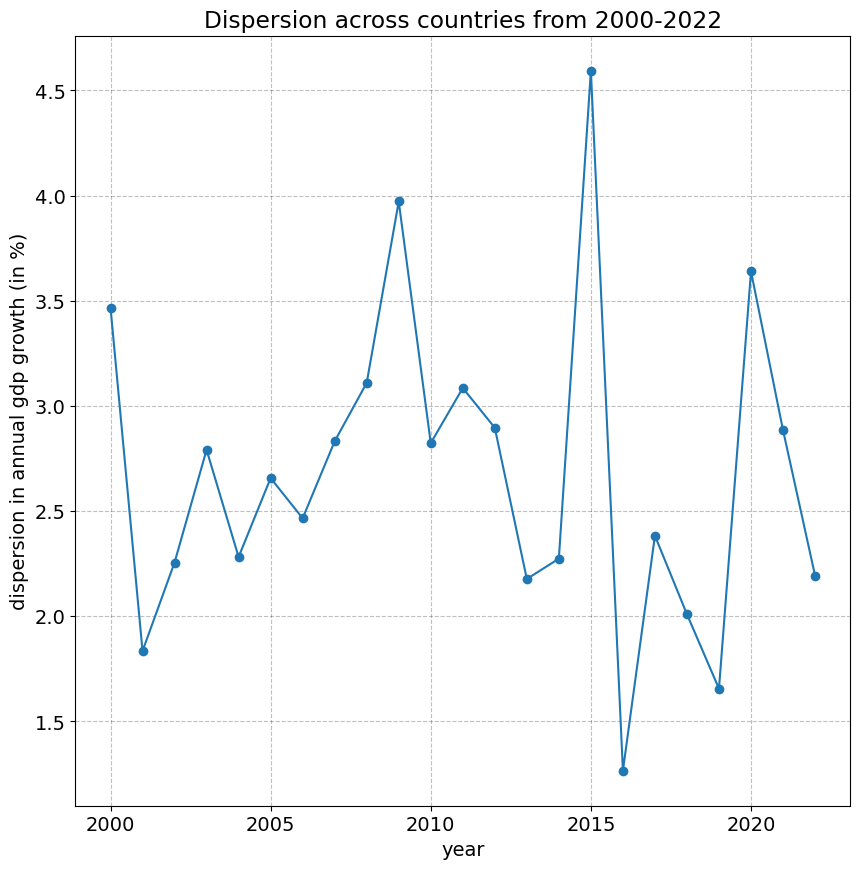

In [25]:
## it might be interesting to plot the summary statistic across countries: 
## for example we plot the empirical standard deviation: 

## plotting yearly dispersion across countries
fig_0 = plt.figure(frameon=True,figsize=(10,10), dpi=100)
ax = fig_0.add_subplot(1,1,1)

# Loop through each country in gdp_long_subset and plot its time series
#ax.plot(gdp_growth['year'], gdp_growth['year_sd_gdp_growth'])
description_wide.loc["std"].plot(ax=ax,style='-o')
#ax.legend(bbox_to_anchor=(0.185, 0.18))
ax.set_xlabel('year')
#plt.xticks(rotation=45)
ax.set_ylabel('dispersion in annual gdp growth (in %)')
ax.set_title('Dispersion across countries from 2000-2022')
plt.show();


Here we change the format of the data set from wide to long. Especially for the later merge with the debt data it is easier to have it in the long format.

In [26]:
gdp_growth_long = pd.melt(gdp_world_bank, id_vars=['Countries'], value_vars = ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
                                                                                '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020','2021','2022'],
var_name='year', value_name='annual_gdp_growth')
gdp_growth_long.head(800)


,Countries,year,annual_gdp_growth
0,Austria,2000,3.375722
1,Belgium,2000,3.716679
2,Greece,2000,3.919771
3,Italy,2000,3.786955
4,Lithuania,2000,3.695525
...,...,...,...
616,Slovak Republic,2022,1.750448
617,Latvia,2022,3.358474
618,Bulgaria,2022,3.926432
619,Czechia,2022,2.351004


# Descriptive Statistics

Now we look at descriptive statistics of each country across time. 

In [27]:
# Sorting the countries together
gdp_growth_long_sort = gdp_growth_long.sort_values(['Countries','year'])

# calculating the deviation from mean
# First i calculate mean gdp growth per country over all years
gdp_growth_mean = gdp_growth_long_sort.groupby('Countries')['annual_gdp_growth'].mean().rename('country_mean_gdp_growth')

# Joining the mean gdp growth back to the original dataframe
gdp_growth = gdp_growth_long_sort.join(gdp_growth_mean, on='Countries')

# Calculating the deviation from each country's mean gdp growth
gdp_growth['gdp_mean_dev'] = gdp_growth['annual_gdp_growth'] - gdp_growth['country_mean_gdp_growth']

gdp_growth.head(30)


,Countries,year,annual_gdp_growth,country_mean_gdp_growth,gdp_mean_dev
0,Austria,2000,3.375722,1.511706,1.864016
27,Austria,2001,1.267168,1.511706,-0.244538
54,Austria,2002,1.651554,1.511706,0.139847
81,Austria,2003,0.941471,1.511706,-0.570236
108,Austria,2004,2.735120,1.511706,1.223414
135,Austria,2005,2.244065,1.511706,0.732359
162,Austria,2006,3.454042,1.511706,1.942335
189,Austria,2007,3.727415,1.511706,2.215709
216,Austria,2008,1.460424,1.511706,-0.051283
243,Austria,2009,-3.764578,1.511706,-5.276285


In [28]:
# Annahme: gdp_growth_long ist dein DataFrame im long-Format mit den Spalten 'Countries', 'year' und 'gdp_growth'

# Finde das Land mit dem niedrigsten Wert in der Spalte 'gdp_growth' für jedes Jahr
min_growth_per_year = gdp_growth.groupby('year')['annual_gdp_growth'].idxmin()

# Extrahiere das entsprechende Land für jedes Jahr
countries_with_min_growth_per_year = gdp_growth.loc[min_growth_per_year, ['year', 'Countries', 'annual_gdp_growth']]

print("Countries with the lowest annual gdp growth for each year:")
print(countries_with_min_growth_per_year)



Countries with the lowest annual gdp growth for each year:
     year        Countries  annual_gdp_growth
22   2000  Slovak Republic           1.166527
53   2001            Malta          -1.174697
65   2002          Germany          -0.197974
86   2003         Portugal          -0.930521
134  2004            Malta           0.140269
137  2005           Greece           0.599142
167  2006         Portugal           1.625034
207  2007          Hungary           0.277373
232  2008          Estonia          -5.132001
247  2009        Lithuania         -14.838608
272  2010           Greece          -5.477808
299  2011           Greece         -10.149315
326  2012           Greece          -7.086697
366  2013           Cyprus          -6.553078
393  2014           Cyprus          -1.829309
407  2015           Greece          -0.196088
434  2016           Greece          -0.487173
461  2017           Greece           1.092149
489  2018            Italy           0.925811
516  2019            

In [29]:
## country with the highest gdp growth: 

# Finde das Land mit dem niedrigsten Wert in der Spalte 'gdp_growth' für jedes Jahr
max_growth_per_year = gdp_growth.groupby('year')['annual_gdp_growth'].idxmax()

# Extrahiere das entsprechende Land für jedes Jahr
countries_with_max_growth_per_year = gdp_growth.loc[max_growth_per_year, ['year', 'Countries', 'annual_gdp_growth']]

print("Countries with the highest annual gdp growth for each year:")
print(countries_with_max_growth_per_year)


Countries with the highest annual gdp growth for each year:
     year        Countries  annual_gdp_growth
26   2000            Malta          19.681269
31   2001        Lithuania           6.526109
77   2002           Latvia           7.088129
85   2003        Lithuania          10.565957
116  2004          Romania          10.428113
158  2005           Latvia          10.720366
185  2006           Latvia          11.971836
193  2007        Lithuania          11.107480
224  2008          Romania           9.307467
263  2009           Poland           2.832184
292  2010  Slovak Republic           6.716633
313  2011          Estonia           7.263085
347  2012           Latvia           7.042247
377  2013            Malta           5.473356
388  2014          Ireland           8.828999
415  2015          Ireland          24.475253
447  2016           Cyprus           6.454554
485  2017            Malta          10.869269
496  2018          Ireland           8.470295
539  2019           

# Time Series of some specific countries

In [30]:
from collections import Counter
print("Counting how often a EU-country had the highest gdp growth per year: \n",Counter(countries_with_max_growth_per_year.Countries))
print("Counting how often a EU-country had the lowest gdp growth per year: \n", Counter(countries_with_min_growth_per_year.Countries))

Counting how often a EU-country had the highest gdp growth per year: 
 Counter({'Ireland': 6, 'Malta': 4, 'Latvia': 4, 'Lithuania': 3, 'Romania': 2, 'Poland': 1, 'Slovak Republic': 1, 'Estonia': 1, 'Cyprus': 1})
Counting how often a EU-country had the lowest gdp growth per year: 
 Counter({'Greece': 7, 'Malta': 2, 'Portugal': 2, 'Estonia': 2, 'Cyprus': 2, 'Italy': 2, 'Slovak Republic': 1, 'Germany': 1, 'Hungary': 1, 'Lithuania': 1, 'Spain': 1, 'Finland': 1})


In [31]:
## creating own data sets for Ireland, Greece, Malta, Lithuania,Latvia, Portugal, Italy to later get all in one plot 

#I = (gdp_growth_long.Countries == 'Ireland' or 'Greece' or 'Malta' or 'Lithuania' or 'Latvia' or 'Portugal' or 'Italy')
#gdp_long_subset = gdp_growth_long.loc[I,:]

countries_to_select_min = ['Greece', 'Portugal', 'Estonia', 'Cyprus']
countries_to_select_max = ['Ireland', 'Malta', 'Latvia']

I = gdp_growth['Countries'].isin(countries_to_select_min)
gdp_long_subset_min = gdp_growth.loc[I, :]



J = gdp_growth['Countries'].isin(countries_to_select_max)
gdp_long_subset_max = gdp_growth.loc[J, :]


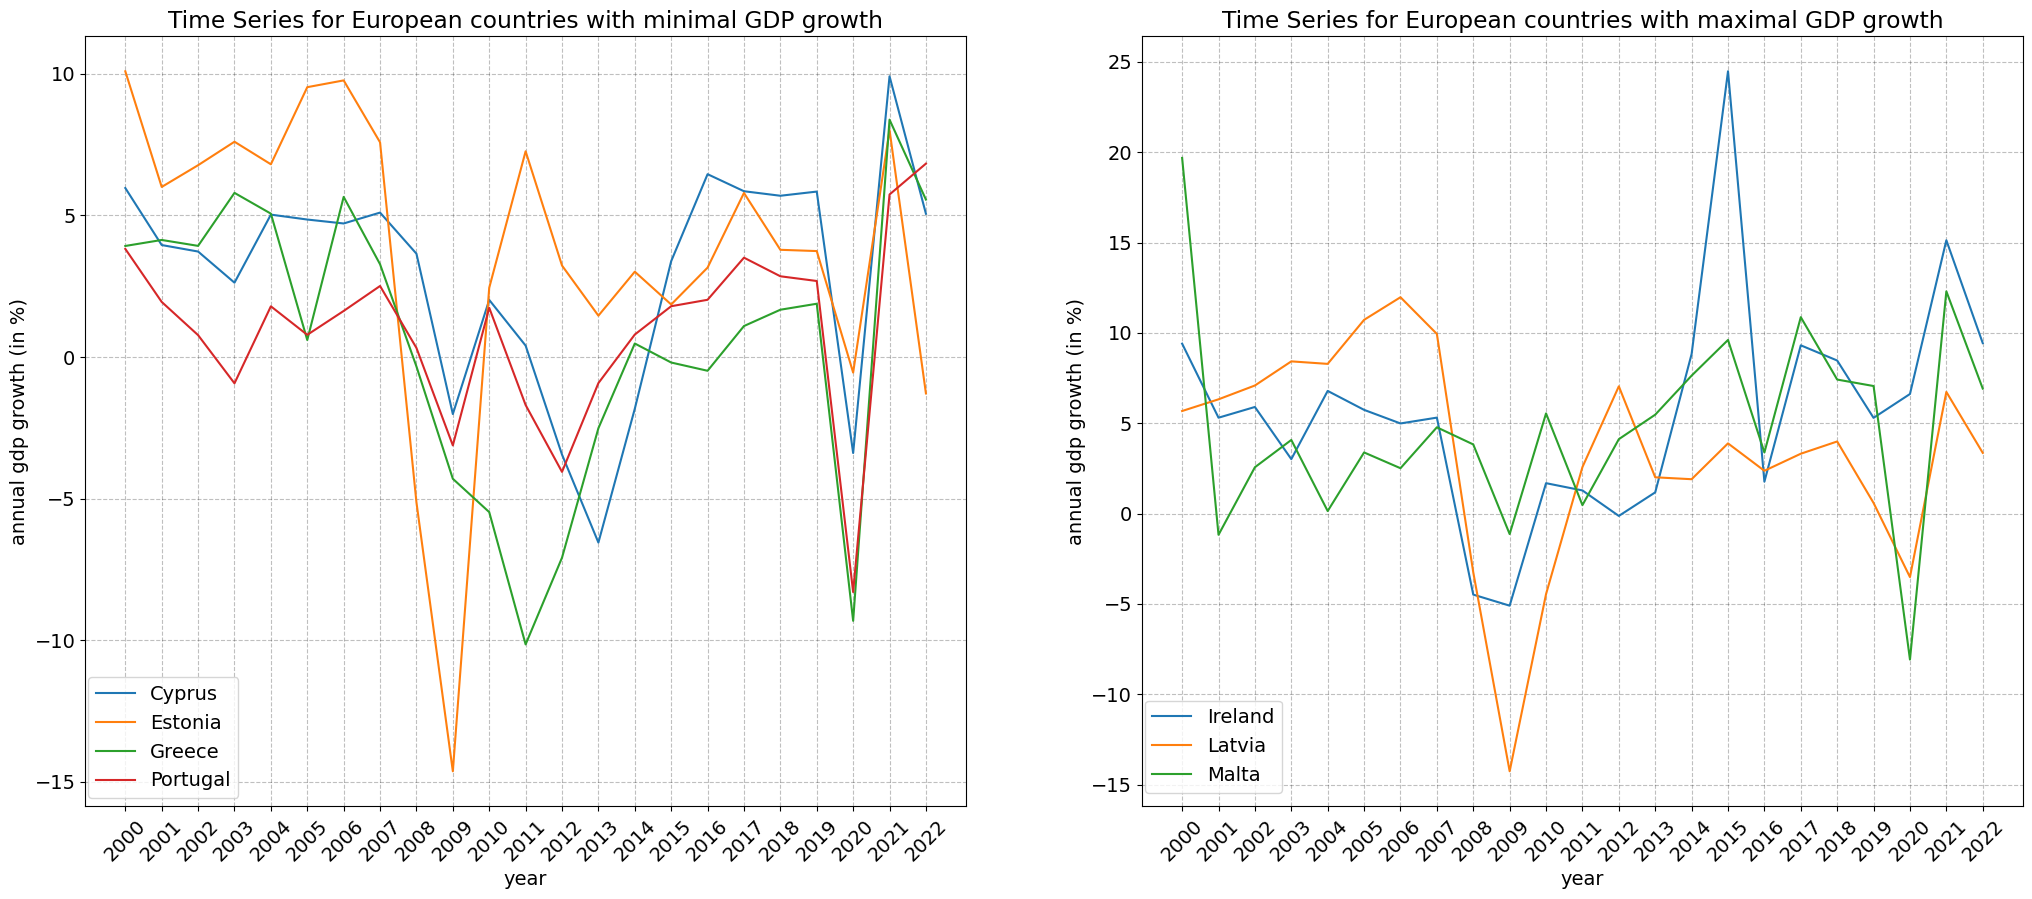

In [32]:
## now we plot some of the outliers (in min and max)
## idea to have two plots next to each other, one only containing min and one only containing max

fig = plt.figure(frameon=True,figsize=(25,10), dpi=100)
ax = fig.add_subplot(1,2,1)

# Loop through each country in gdp_long_subset and plot its time series
for country, data in gdp_long_subset_min.groupby('Countries'):
    ax.plot(data['year'], data['annual_gdp_growth'], label=country)

ax.legend(bbox_to_anchor=(0.185, 0.18))
ax.set_xlabel('year')
plt.xticks(rotation=45)
ax.set_ylabel('annual gdp growth (in %)')
ax.set_title('Time Series for European countries with minimal GDP growth')


az = fig.add_subplot(1,2,2)
for country, data in gdp_long_subset_max.groupby('Countries'):
    az.plot(data['year'], data['annual_gdp_growth'], label=country)


az.legend(bbox_to_anchor=(0.17, 0.15))
az.set_xlabel('year')
plt.xticks(rotation=45)
az.set_ylabel('annual gdp growth (in %)')
az.set_title('Time Series for European countries with maximal GDP growth')

plt.show();



next steps would be to (do interactive plots and) join with the debt data

Interactive plots are done now

In [33]:
countries = list(gdp_world_bank['Countries'])
print(countries)

['Austria', 'Belgium', 'Greece', 'Italy', 'Lithuania', 'Portugal', 'Slovenia', 'Spain', 'Romania', 'Luxembourg', 'Ireland', 'Germany', 'Finland', 'Denmark', 'Croatia', 'Cyprus', 'Estonia', 'France', 'Hungary', 'Netherlands', 'Poland', 'Sweden', 'Slovak Republic', 'Latvia', 'Bulgaria', 'Czechia', 'Malta']


In [34]:
gdp_growth.head(5)

,Countries,year,annual_gdp_growth,country_mean_gdp_growth,gdp_mean_dev
0,Austria,2000,3.375722,1.511706,1.864016
27,Austria,2001,1.267168,1.511706,-0.244538
54,Austria,2002,1.651554,1.511706,0.139847
81,Austria,2003,0.941471,1.511706,-0.570236
108,Austria,2004,2.735120,1.511706,1.223414


In [35]:
# Define the list of countries for which we want to have a drop down 
countries = list(gdp_world_bank['Countries'])

In [36]:
# This function tells the widget how the plot should look at a specific parametrization 
def interactive_figure(country):
    # Create a figure
    fig = plt.figure(frameon=True,figsize=(20,10), dpi=100)
    ax = fig.add_subplot(1,1,1)
    
    # Plot the selected country's GDP growth time series
    selected_country_data = gdp_growth[gdp_growth['Countries'] == country]
    ax.plot(selected_country_data['year'], selected_country_data['annual_gdp_growth'])
    
    # Set the title
    ax.set_xlabel('year')
    ax.set_ylabel('annual gdp growth (in %)')
    ax.set_title("Time Series of GDP Growth for {}".format(country))
    
    # Show the plot
    plt.show()


In [37]:
# Create the dropdown widget
# semikolon avoids additional text to be printed 
widgets.interact(interactive_figure, country=countries);

interactive(children=(Dropdown(description='country', options=('Austria', 'Belgium', 'Greece', 'Italy', 'Lithu…